In [88]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.metrics import accuracy_score,log_loss

In [89]:
kyph=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Kyphosis\\Kyphosis.csv")
kyph

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [90]:
kyph.isnull().sum()

Kyphosis    0
Age         0
Number      0
Start       0
dtype: int64

In [91]:
X,y=kyph.drop("Kyphosis",axis=1),kyph["Kyphosis"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=26,stratify=y)


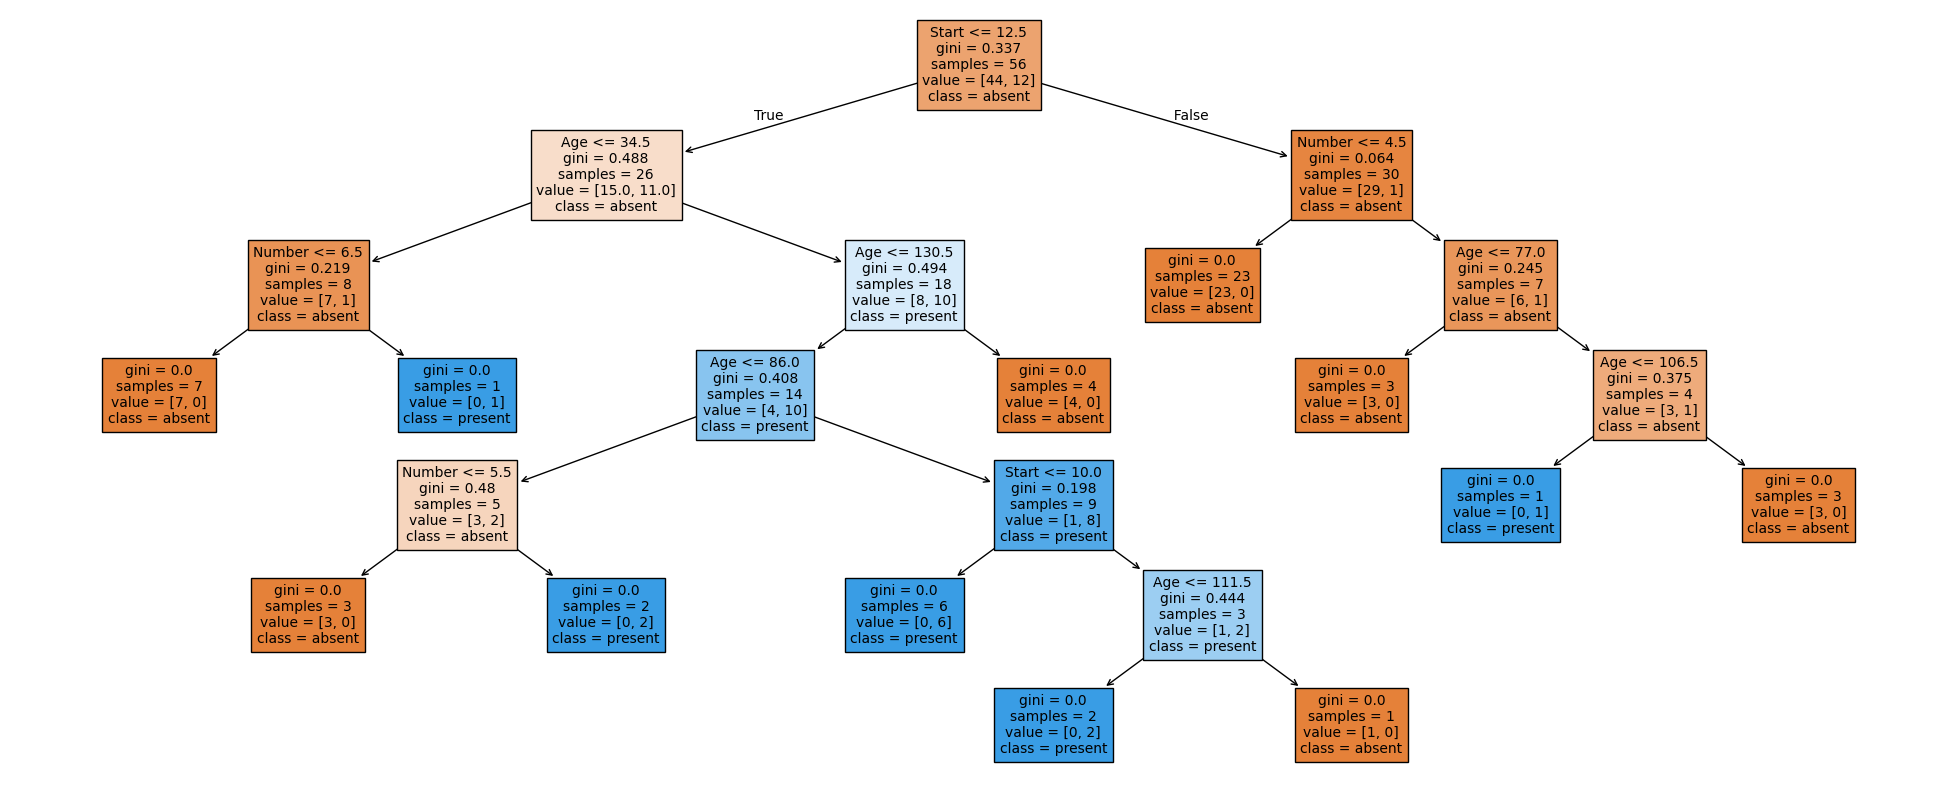

In [92]:
dtc=DecisionTreeClassifier(random_state=26)
dtc.fit(X_train,y_train)
plt.figure(figsize=(25,10))
plot_tree(dtc,feature_names=list(X.columns),class_names=["absent","present"],filled=True,fontsize=10)
plt.show()

In [93]:
y_pred=dtc.predict(X_test)
print("Acc=",accuracy_score(y_test,y_pred))
y_pred_prob=dtc.predict_proba(X_test)
print("log loss=",log_loss(y_test,y_pred_prob))

Acc= 0.68
log loss= 11.533969084517489


In [94]:
f1,f2=44/(44+12),12/(44+12)
gini=f1*(1-f1) + f2*(1-f2)
gini

0.33673469387755106

In [95]:
f1,f2=40/(40+60),60/(40+60)
gini=f1*(1-f1) + f2*(1-f2)
gini

0.48

In [96]:
f1,f2=80/(80+20),20/(80+20)
gini=f1*(1-f1) + f2*(1-f2)
gini

0.32

In [97]:
f1,f2=10/(10+90),90/(10+90)
gini=f1*(1-f1) + f2*(1-f2)
gini

0.18

In [98]:
f1,f2=29/(29+1),1/(29+1)
gini=f1*(1-f1) + f2*(1-f2)
gini

0.06444444444444444

In [99]:
f1,f2=15/(15+11),11/(15+11)
gini=f1*(1-f1) + f2*(1-f2)
gini

0.4881656804733727

## depths


In [126]:
depths=[1,2,3,4,5]
scores=[]
for d in depths:
    dtc=DecisionTreeClassifier(random_state=26,max_depth=d)
    dtc.fit(X_train,y_train)
    y_pred_prob=dtc.predict_proba(X_test)
    scores.append([d,log_loss(y_test,y_pred_prob)])
df_scores=pd.DataFrame(scores,columns=["depths","score"])
df_scores.sort_values("score")

,depths,score
0,1,0.404030
1,2,1.668450
2,3,4.525502
3,4,4.582748
4,5,11.577914


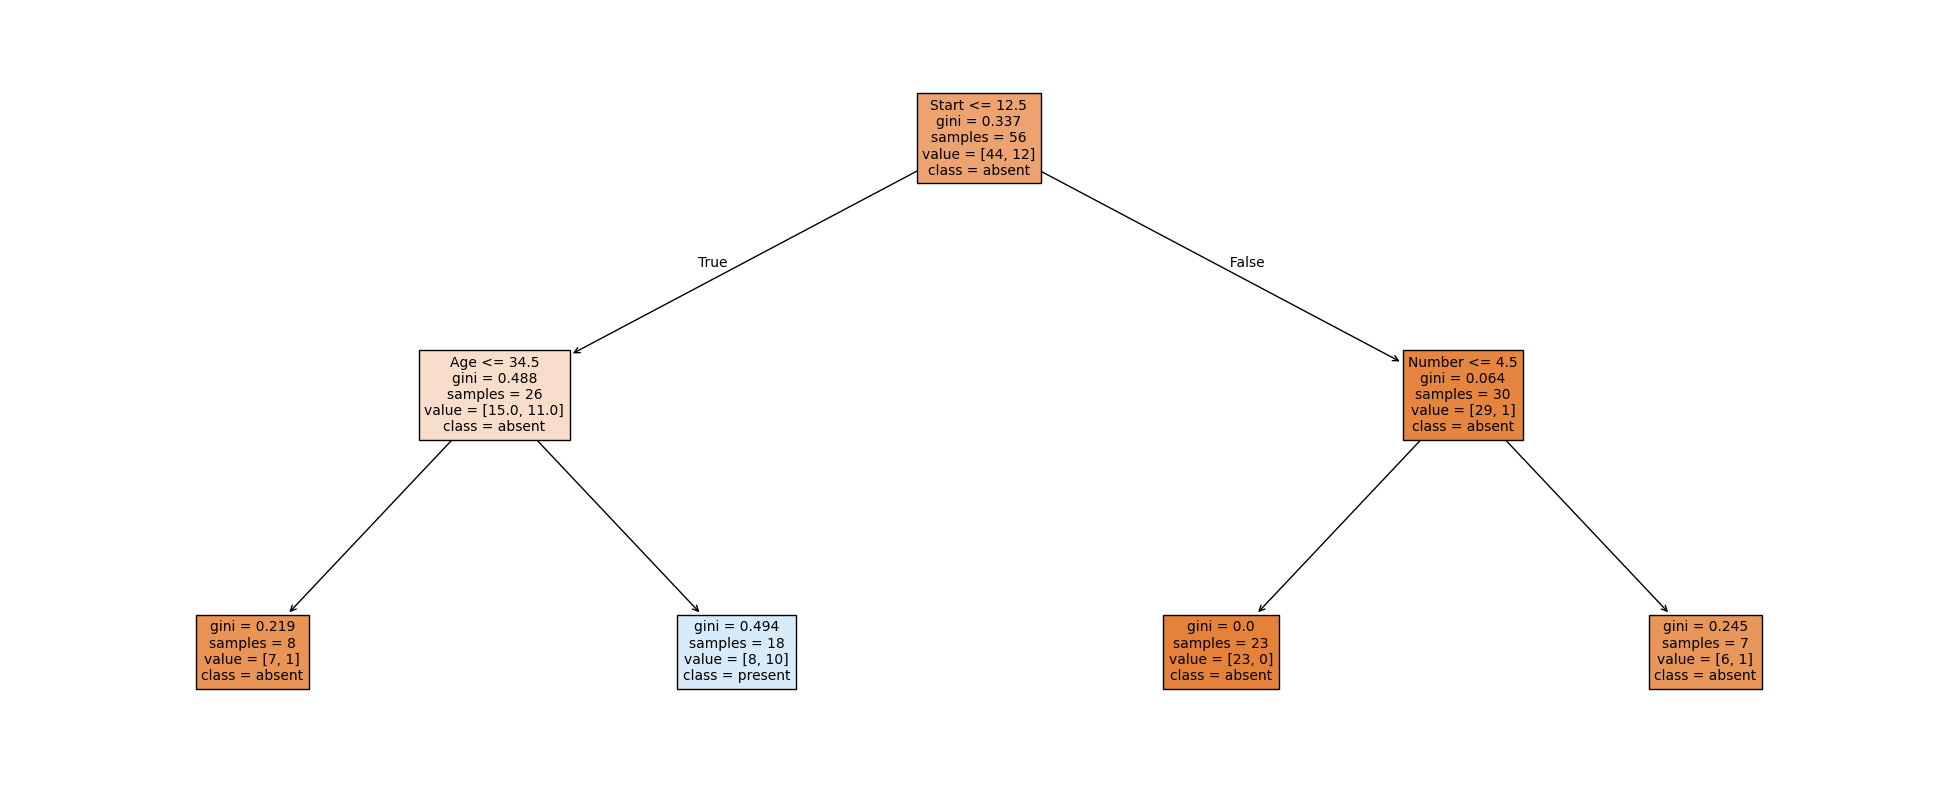

In [101]:
dtc=DecisionTreeClassifier(random_state=26,max_depth=2)

dtc.fit(X_train,y_train)
plt.figure(figsize=(25,10))
plot_tree(dtc,feature_names=list(X.columns),class_names=["absent","present"],filled=True,fontsize=10)
plt.show()

## Splits

In [102]:
splits=[2,5,10,20,30]
scores=[]
for s in splits:
    dtc=DecisionTreeClassifier(random_state=26,min_samples_split=s)
    dtc.fit(X_train,y_train)
    y_pred_prob=dtc.predict_proba(X_test)
    scores.append([s,log_loss(y_test,y_pred_prob)])
df_scores=pd.DataFrame(scores,columns=["split","score"])
df_scores.sort_values("score")

,split,score
3,20,1.668450
4,30,1.714052
2,10,4.562643
1,5,8.717436
0,2,11.533969


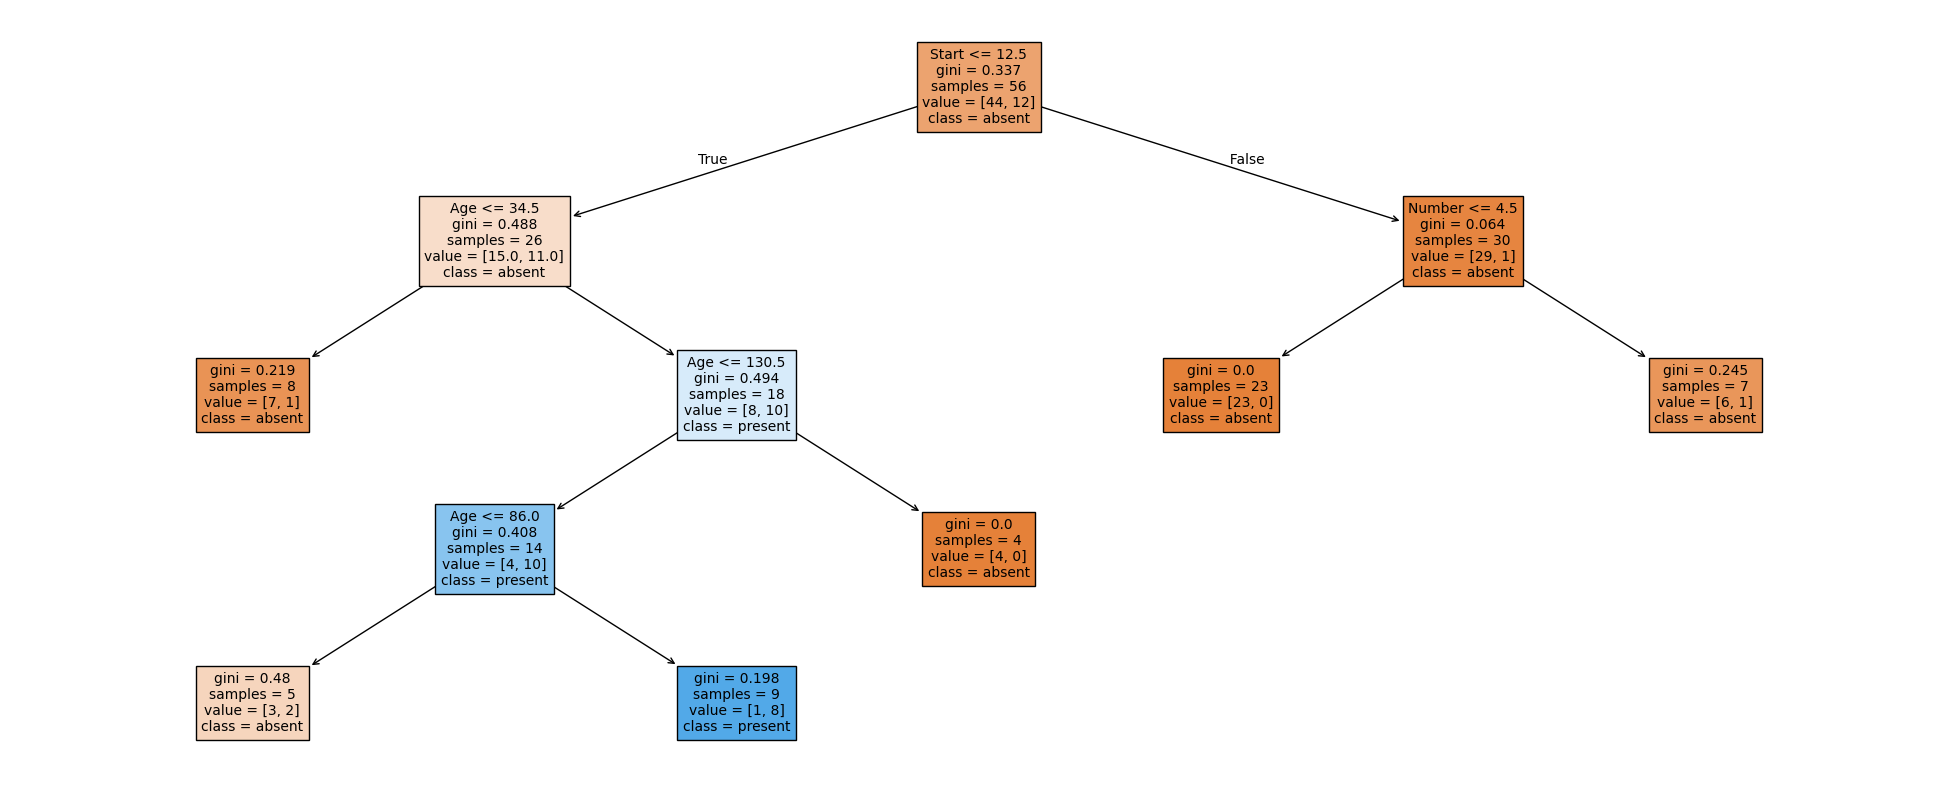

In [103]:
dtc=DecisionTreeClassifier(random_state=26,min_samples_split=10)

dtc.fit(X_train,y_train)
plt.figure(figsize=(25,10))
plot_tree(dtc,feature_names=list(X.columns),class_names=["absent","present"],filled=True,fontsize=10)
plt.show()

## leaves

In [104]:
leaves=[1,5,8,10,20]
# leaves=[10,20,1]

scores=[]
for l in leaves:
    dtc=DecisionTreeClassifier(random_state=26,min_samples_leaf=l)
    dtc.fit(X_train,y_train)
    y_pred_prob=dtc.predict_proba(X_test)
    scores.append([s,log_loss(y_test,y_pred_prob)])
df_scores=pd.DataFrame(scores,columns=["leaves","score"])
df_scores.sort_values("score")

,leaves,score
2,30,0.358709
4,30,0.404030
3,30,1.703706
1,30,1.803195
0,30,11.533969


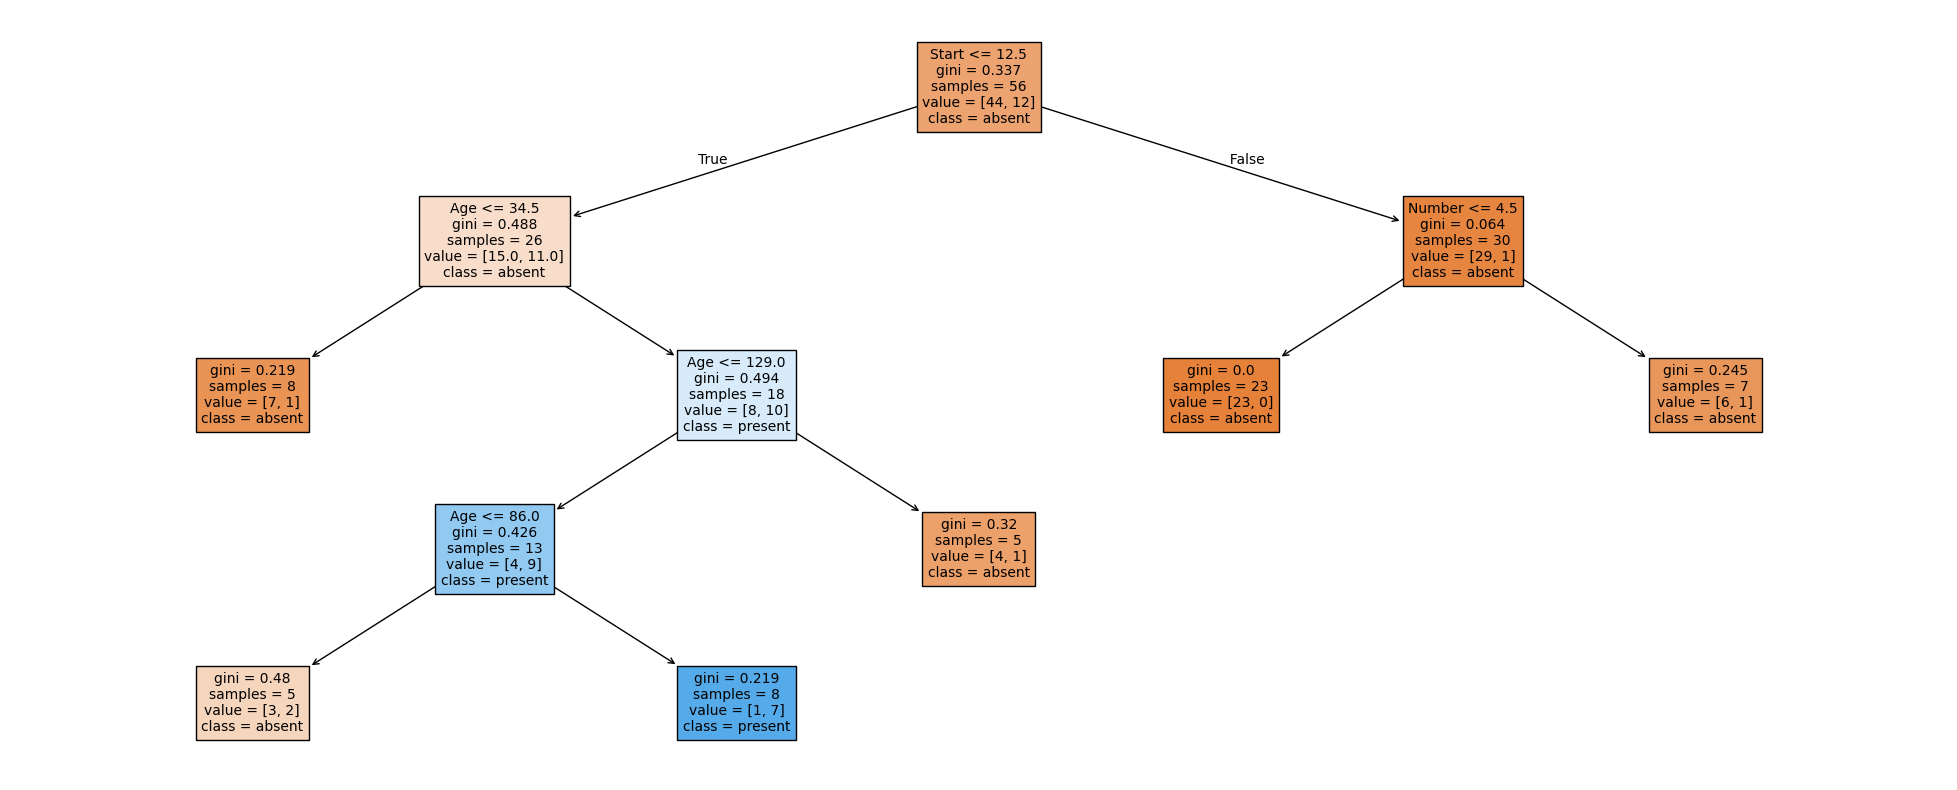

In [116]:
dtc=DecisionTreeClassifier(random_state=26,min_samples_leaf=5)

dtc.fit(X_train,y_train)
plt.figure(figsize=(25,10))
plot_tree(dtc,feature_names=list(X.columns),class_names=["absent","present"],filled=True,fontsize=10)
plt.show()

In [124]:
depths=np.arange(1,7)
splits=np.arange(2,25)
leaves=np.arange(1,15)
scores=[]
for d in tqdm(depths):
    for s in splits:
        for l in leaves:
             dtc=DecisionTreeClassifier(random_state=26,min_samples_leaf=l,min_samples_split=s,max_depth=d)
    dtc.fit(X_train,y_train)
    y_pred_prob=dtc.predict_proba(X_test)
    scores.append([d,s,l,log_loss(y_test,y_pred_prob)])
df_scores=pd.DataFrame(scores,columns=["depths","split","leaves","score"])
df_scores.sort_values("score")
    

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 110.68it/s]


,depths,split,leaves,score
0,1,24,14,0.404030
1,2,24,14,1.713102
2,3,24,14,1.713102
3,4,24,14,1.713102
4,5,24,14,1.713102
5,6,24,14,1.713102


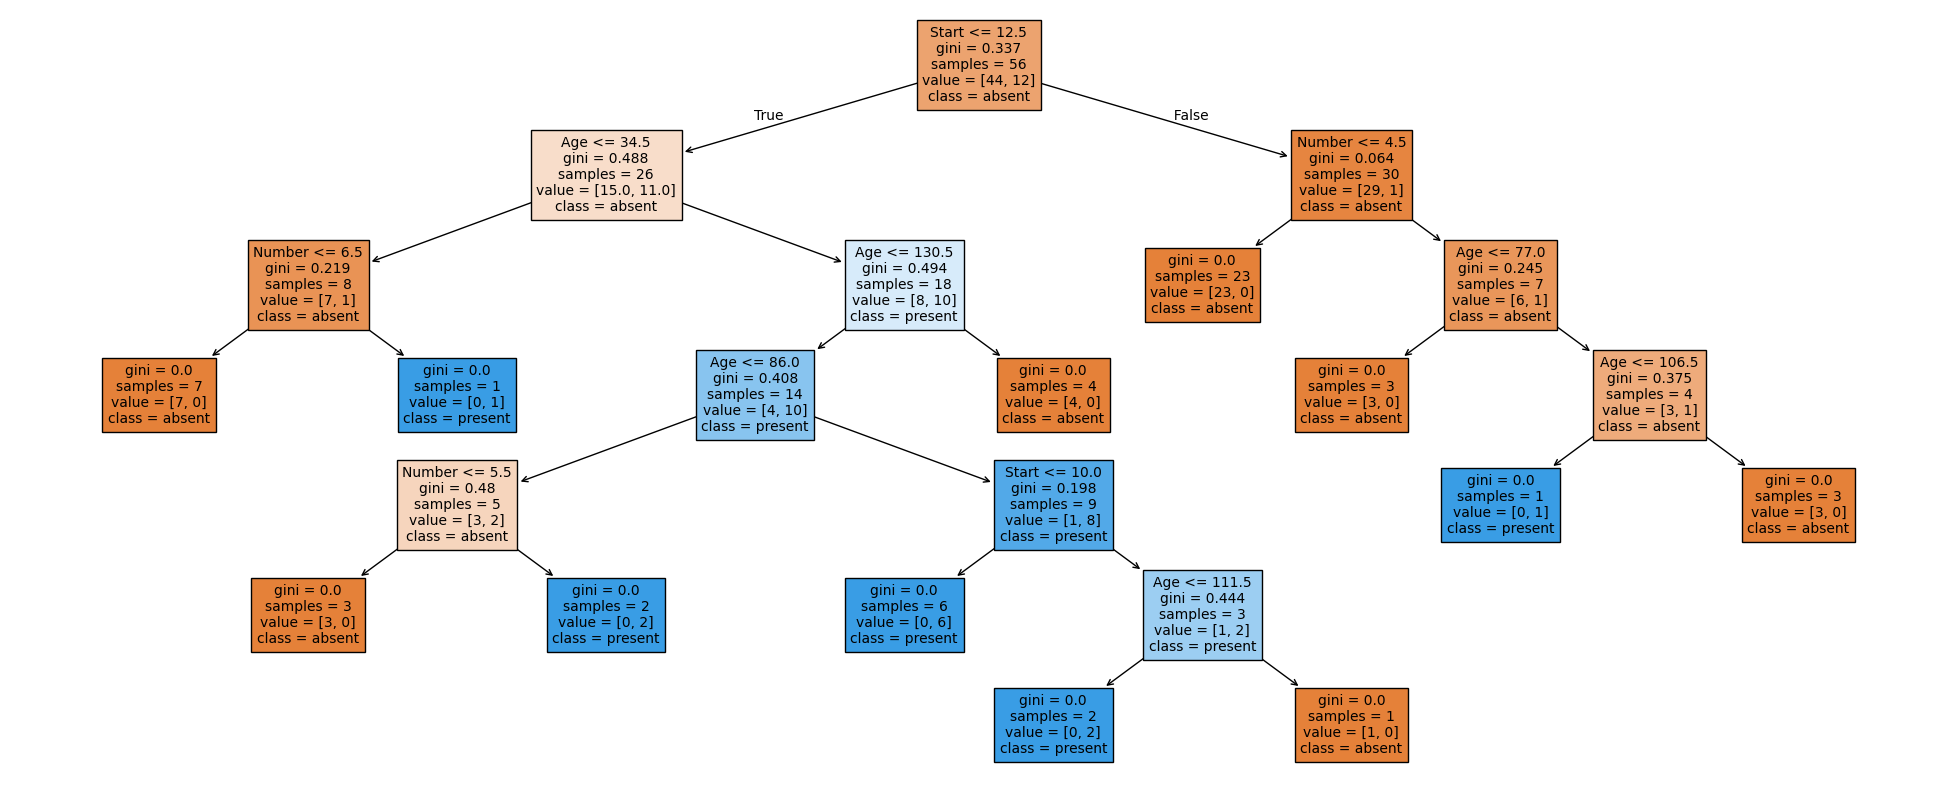

In [111]:
# dtc=DecisionTreeClassifier(random_state=26,min_samples_leaf=1)

# dtc.fit(X_train,y_train)
# plt.figure(figsize=(25,10))
# plot_tree(dtc,feature_names=list(X.columns),class_names=["absent","present"],filled=True,fontsize=10)
# plt.show()

## best tree

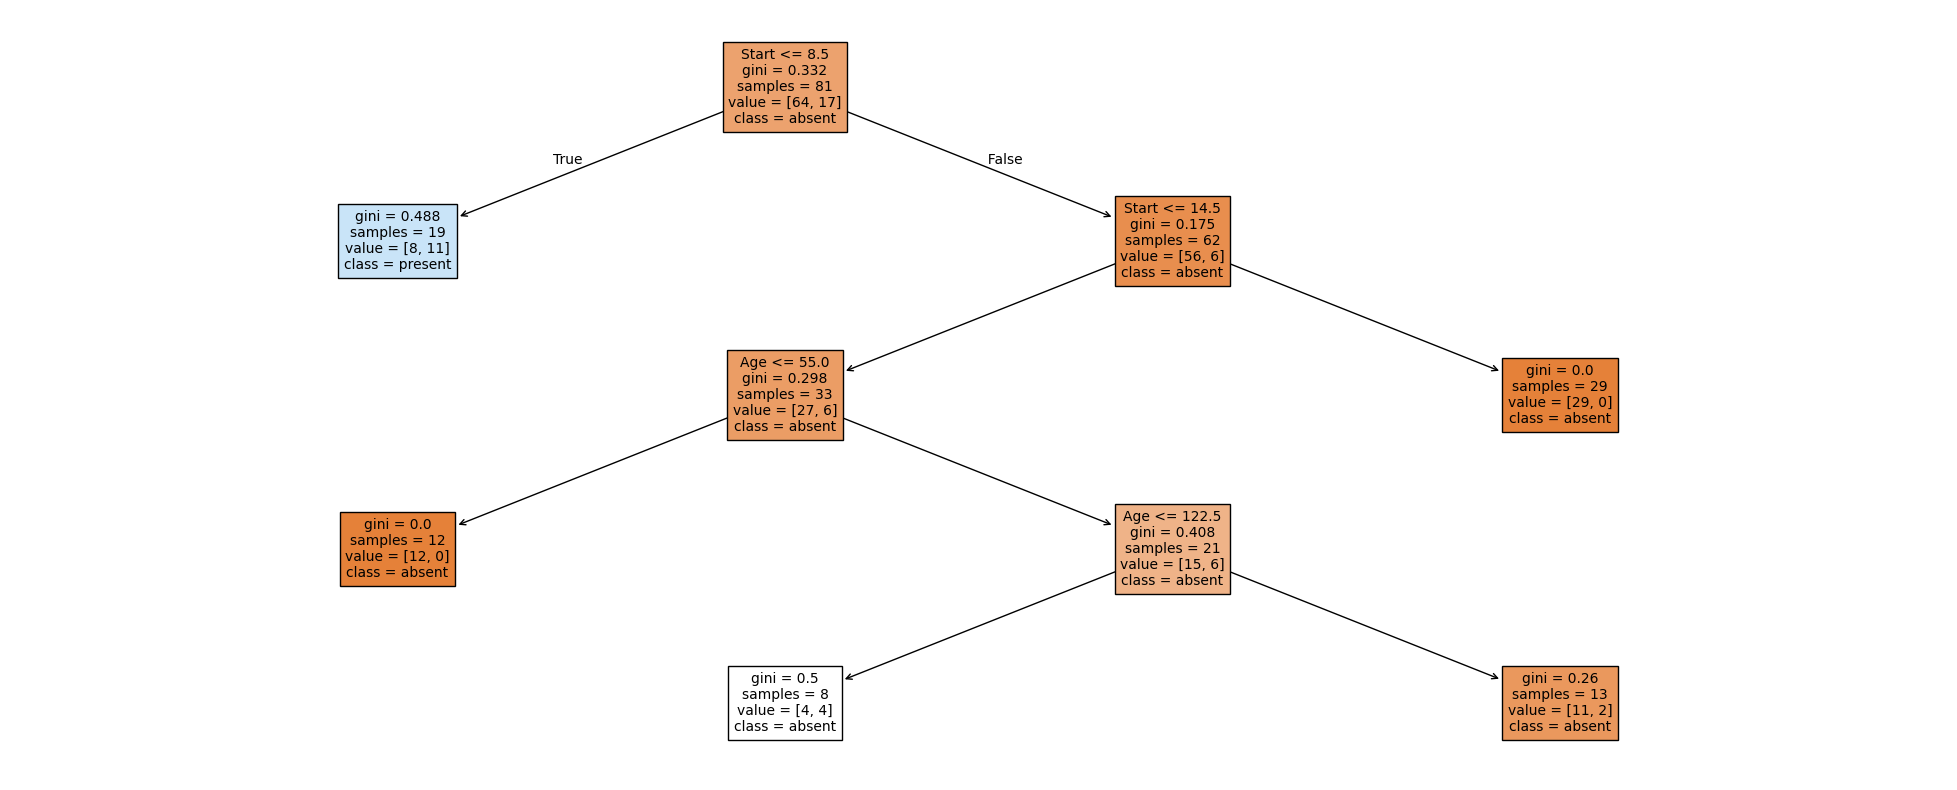

In [118]:
bm=DecisionTreeClassifier(random_state=26,min_samples_leaf=8,max_depth=4, min_samples_split=20)
bm.fit(X,y)
plt.figure(figsize=(25,10))
plot_tree(bt,feature_names=list(X.columns),class_names=["absent","present"],filled=True,fontsize=10)
plt.show()

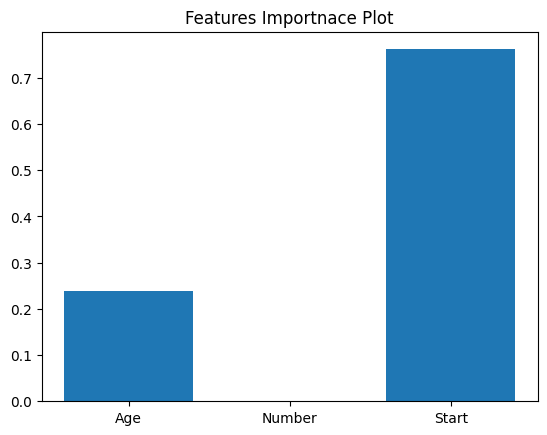

In [123]:
df_imp=pd.DataFrame({"feature":X.columns,"importance": bm.feature_importances_})
plt.bar(df_imp["feature"],df_imp["importance"])
plt.title("Features Importnace Plot")
plt.show()